In [2]:
import json
import os
import ctypes

import numpy as np
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt

from pycocotools.coco import COCO
os.environ["SM_FRAMEWORK"]="tf.keras"
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.utils import Sequence, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten

from keras_preprocessing.image import img_to_array

import segmentation_models as sm

Segmentation Models: using `tf.keras` framework.


In [3]:
ctypes.windll.kernel32.SetThreadExecutionState(0x80000002)


-2147483648

In [4]:
test_img="./arcade/stenosis/test/images/"
train_img="./arcade/stenosis/train/images/"
val_img="./arcade/stenosis/val/images/"

In [5]:
js_train="./arcade/stenosis/train/annotations/train.json"
js_val="./arcade/stenosis/val/annotations/val.json"
js_test="./arcade/stenosis/test/annotations/test.json"

with open (js_train,"r") as f:
    js_tra=json.load(f)

with open (js_val,"r") as b:
    js_v=json.load(b)

with open (js_test,"r") as c:
    js_te=json.load(c)

In [6]:
print(f" count train:{len(os.listdir(train_img))}")
print(f" count val:{len(os.listdir(val_img))}")
print(f" count test:{len(os.listdir(test_img))}")

 count train:1000
 count val:200
 count test:300


In [7]:
img_filers=os.listdir(train_img)
x_train=[]
coco=COCO(js_train)
img_ids=coco.getImgIds()
for img_id in img_ids:
    img_p=coco.loadImgs(img_id)[0]
    img=os.path.join(train_img,img_p["file_name"])
    img=load_img(img,target_size=(512,512),color_mode="grayscale")
    img=img_to_array(img)
    x_train.append(img)
x_train=np.array(x_train)

img_filers_test=os.listdir(test_img)
x_test=[]
for j in img_filers_test:
    img_p2=os.path.join(test_img,j)
    img2=load_img(img_p2,target_size=(512,512),color_mode="grayscale")
    img2=img_to_array(img2)
    x_test.append(img2)
x_test=np.array(x_test)

img_filers_val=os.listdir(val_img)
val_a=[]
for k in img_filers_val:
    img_p3=os.path.join(val_img, k)
    img3=load_img(img_p3,target_size=(512,512),color_mode="grayscale")
    img3=img_to_array(img3)
    val_a.append(img3)
val_a=np.array(val_a)



loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


In [8]:
print("train:",x_train.shape)
print("test:",x_test.shape)
print("val:",val_a.shape)

train: (1000, 512, 512, 1)
test: (300, 512, 512, 1)
val: (200, 512, 512, 1)


In [9]:
def make_masks(json_path):
    coco=COCO(json_path)
    img_ids=coco.getImgIds()
    masks=[]

    for img_id in img_ids:

        img_info=coco.loadImgs(img_id)[0]
        anns=coco.loadAnns(coco.getAnnIds(imgIds=img_id))
        mask=np.zeros(
            (img_info["height"],img_info["width"]),
            dtype=np.uint8)
        for ann in anns:
            mask=np.maximum(mask,coco.annToMask(ann))

        mask=Image.fromarray(mask)
        mask=mask.resize(
            (512,512),
            Image.NEAREST)
        masks.append(np.array(mask))
    masks=np.array(masks)
    masks=np.expand_dims(masks,-1)

    return masks

In [10]:
y_train=make_masks(js_train)
y_val=make_masks(js_val)
y_test=make_masks(js_test)

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [11]:
print("val mask:",y_val.shape)
print("test mask:",y_test.shape)
print("train mask:",y_train.shape)

val mask: (200, 512, 512, 1)
test mask: (300, 512, 512, 1)
train mask: (1000, 512, 512, 1)


In [12]:
print(x_train.shape)
print(y_train.shape)

(1000, 512, 512, 1)
(1000, 512, 512, 1)


In [13]:
print(js_tra["images"][0])
print("image:", x_train[0].shape)
print("mask:", y_train[0].shape)

{'id': 676, 'width': 512, 'height': 512, 'file_name': '676.png', 'license': 0, 'flickr_url': '', 'coco_url': '', 'date_captured': 0}
image: (512, 512, 1)
mask: (512, 512, 1)


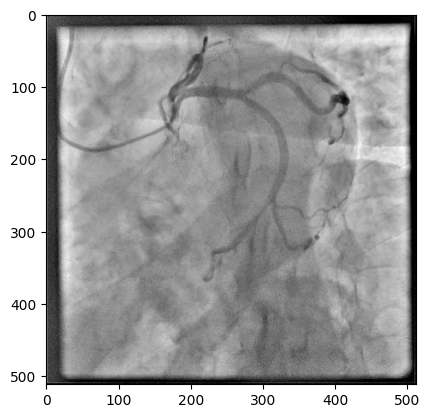

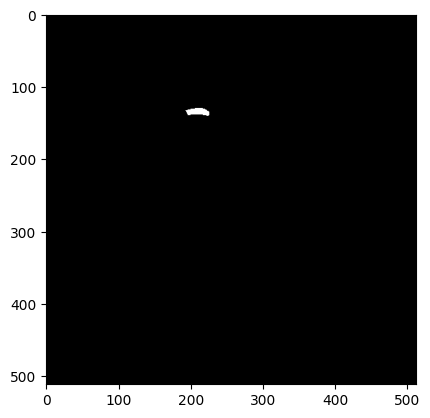

In [14]:
plt.imshow(x_train[0].squeeze(),cmap="gray")
plt.show()

plt.imshow(y_train[0].squeeze(),cmap="gray")
plt.show()

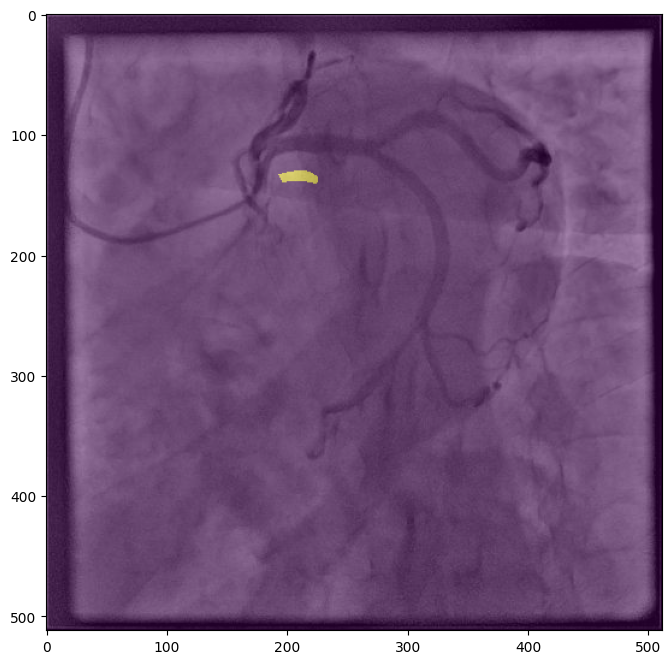

In [15]:
plt.figure(figsize=(8,8))

plt.imshow(x_train[0].squeeze(), cmap="gray")
plt.imshow(y_train[0].squeeze(), alpha=0.5)

plt.show()

In [16]:
x_train=x_train/255.0
val_a=val_a/255.0
x_test=x_test/255.0

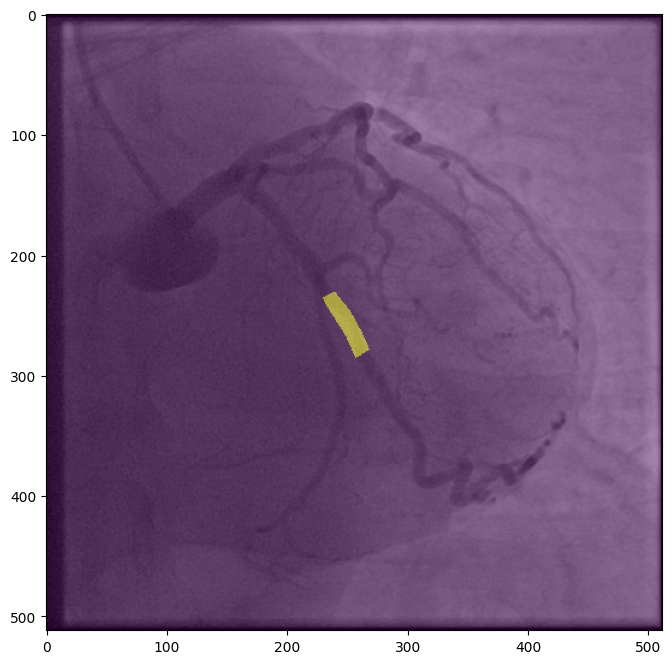

In [17]:
i=0

plt.figure(figsize=(8,8))

plt.imshow(x_test[i].squeeze(), cmap="gray")
plt.imshow(y_test[i].squeeze(), alpha=0.5)

plt.show()

In [18]:
x_tra_=np.repeat(x_train,3,axis=-1)
val_a_=np.repeat(val_a,3,axis=-1)
x_test_rgb=np.repeat(x_test,3,axis=-1)

In [19]:
model=sm.Unet('resnet34',input_shape=(512,512,3),activation="sigmoid",encoder_weights="imagenet",classes=1)

In [20]:
model.compile(optimizer="adam",loss=sm.losses.bce_dice_loss,metrics=[sm.metrics.IOUScore(threshold=0.5)])


In [21]:
gpu=tf.config.list_physical_devices("GPU")
print(gpu)

[]


In [22]:
y_train=y_train.astype("float32")
y_val=y_val.astype("float32")
y_test=y_test.astype("float32")

In [ ]:
history=model.fit(x_tra_,y_train,validation_data=(val_a_,y_val),epochs=50,batch_size=4)

Epoch 1/50


In [28]:
model.save("heart.keras")

In [29]:
print(len(history.history["loss"]))
print(history.history["loss"])

50
[0.9844629168510437, 0.8990098237991333, 0.8731050491333008, 0.8666237592697144, 0.8649857044219971, 0.8592790961265564, 0.845359206199646, 0.8368920087814331, 0.832287609577179, 0.8332118988037109, 0.8244755864143372, 0.8262139558792114, 0.82338947057724, 0.8073495030403137, 0.7944703102111816, 0.7824773788452148, 0.769477903842926, 0.7640453577041626, 0.7528295516967773, 0.7457308173179626, 0.7334864735603333, 0.7211668491363525, 0.7096331119537354, 0.7024093866348267, 0.6999768614768982, 0.6835634708404541, 0.6825432777404785, 0.6825572848320007, 0.678666889667511, 0.6691842079162598, 0.6611103415489197, 0.65525221824646, 0.6501867771148682, 0.650046706199646, 0.6445798277854919, 0.6310797929763794, 0.6400352120399475, 0.6303141713142395, 0.6307281255722046, 0.6129087209701538, 0.6202473640441895, 0.6164476275444031, 0.6070528626441956, 0.6058843731880188, 0.5883485674858093, 0.5875973105430603, 0.5897412300109863, 0.5855942368507385, 0.5845795273780823, 0.5785461664199829]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step


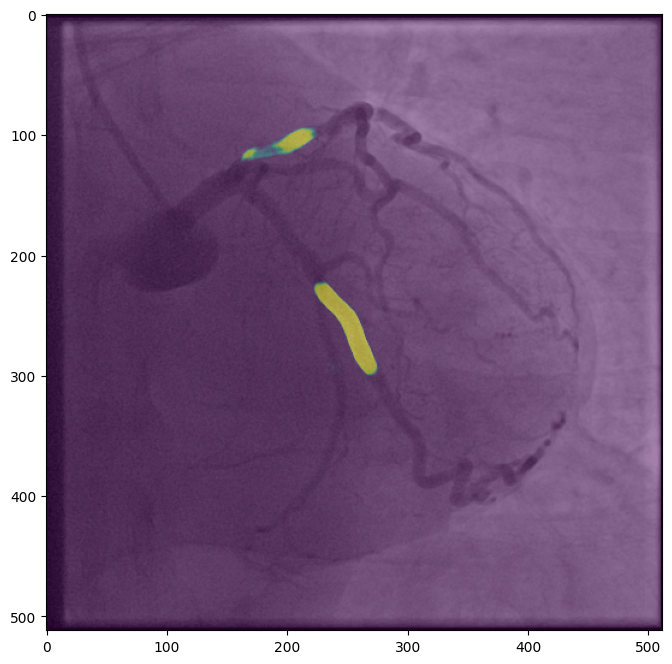

In [30]:
i=0
pred=model.predict(x_test[i:i+1])
plt.figure(figsize=(8,8))

plt.imshow(x_test[i].squeeze(),cmap="gray")
plt.imshow(pred[0].squeeze(),alpha=0.5)

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step


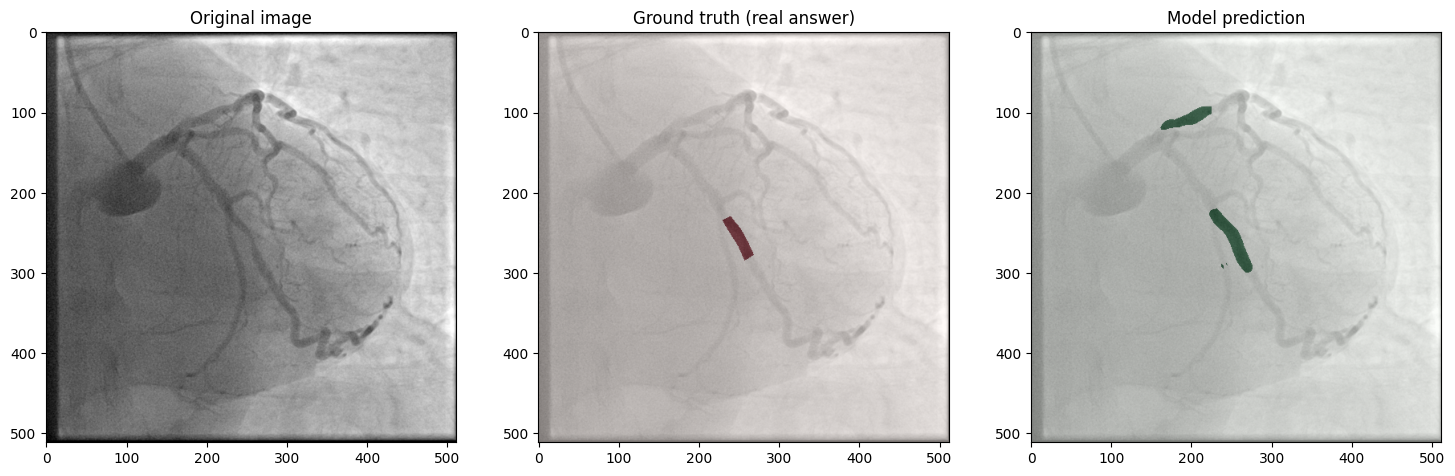

IoU 0.3400274
Dice 0.5074932


In [48]:
i = 0

pred=model.predict(x_test[i:i+1])
pred_mask=(pred[0]>0.05).astype("uint8")

fig,axes=plt.subplots(1,3,figsize=(18, 6))

axes[0].imshow(x_test[i].squeeze(),cmap="gray")
axes[0].set_title("Original image")
axes[1].imshow(x_test[i].squeeze(),cmap="gray")
axes[1].imshow(y_test[i].squeeze(),alpha=0.5,cmap="Reds")
axes[1].set_title("Ground truth (real answer)")
axes[2].imshow(x_test[i].squeeze(),cmap="gray")
axes[2].imshow(pred_mask.squeeze(),alpha=0.5,cmap="Greens")
axes[2].set_title("Model prediction")

plt.show()

from segmentation_models.metrics import IOUScore, FScore
y_single=y_test[i:i+1].astype("float32")
pred_single=pred.astype("float32")
iou=IOUScore(threshold=0.05)
dice=FScore(beta=1, threshold=0.05)

print("IoU",iou(y_single,pred_single).numpy())
print("Dice",dice(y_single,pred_single).numpy())

In [31]:
new_im="F://54.png"
img_loder_test=load_img(new_im,target_size=(512,512),color_mode="grayscale")

img=img_to_array(img_loder_test)
img=img/255.0
img=np.expand_dims(img,axis=0)
pred=model.predict(img)
pred_mask=pred[0]
pred_msk=(pred_mask>0.5).astype("uint8")
print(pred_msk.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step
(512, 512, 1)


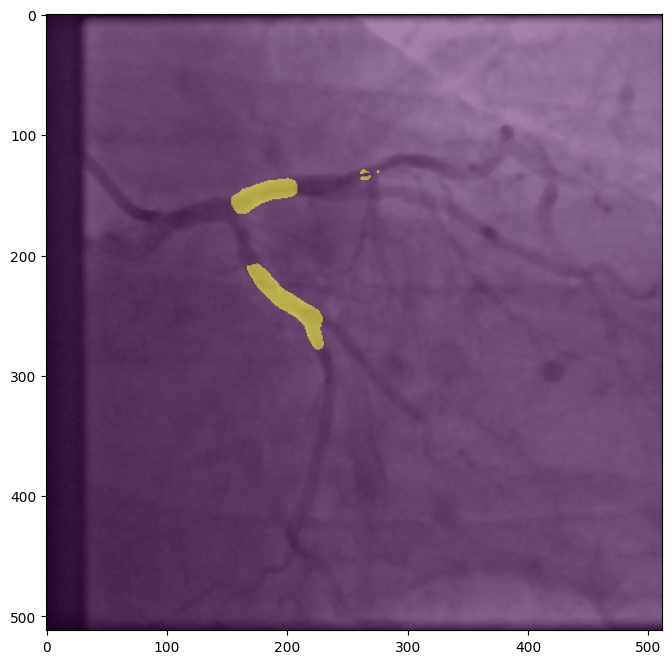

In [32]:
plt.figure(figsize=(8,8))
plt.imshow(img[0].squeeze(), cmap="gray")
plt.imshow(pred_msk.squeeze(),alpha=0.5)
plt.show()

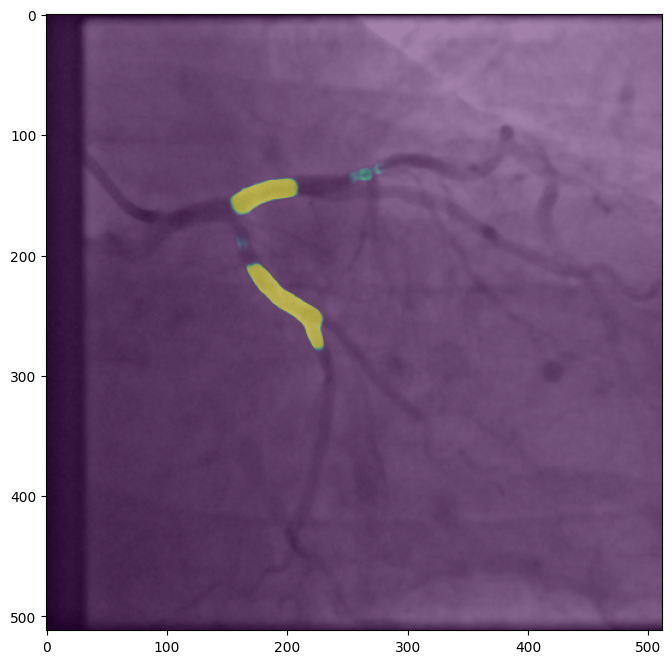

In [33]:
pred_msk=(pred_mask>0.1).astype("uint8")

plt.figure(figsize=(8,8))
plt.imshow(img[0].squeeze(),cmap="gray")
plt.imshow(pred_mask.squeeze(),alpha=0.5)
plt.show()

In [34]:
print(pred.min(), pred.max(), pred.mean())

1.5961671e-23 0.9999626 0.00897069


In [35]:
new_im2="F://165.png"
img_loder_test2=load_img(new_im2,target_size=(512,512),color_mode="grayscale")

img2=img_to_array(img_loder_test2)
img2=img2/255.0
img2=np.expand_dims(img2,axis=0)
pred2=model.predict(img2)
pred_mask2=pred2[0]
pred_msk2=(pred_mask2>0.5).astype("uint8")
print(pred_msk2.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
(512, 512, 1)


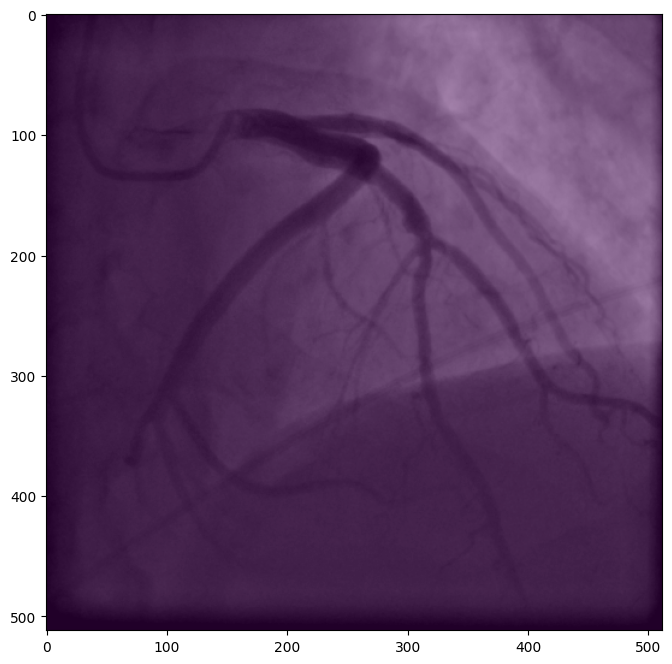

In [36]:
test_again=(pred_mask2>0.1).astype("uint8")

plt.figure(figsize=(8,8))

plt.imshow(img2[0].squeeze(),cmap="gray")
plt.imshow(test_again.squeeze(),alpha=0.5)

plt.show()

In [37]:
print(pred.max())
print(pred.min())
print(np.sum(pred_msk))

0.9999626
1.5961671e-23
2720


In [40]:
from segmentation_models.metrics import IOUScore,FScore
pred_test=model.predict(x_test)

y_test=y_test.astype("float32")

pred_mask2=pred_mask2.astype("float32")

iou=IOUScore(threshold=0.5)
dice=FScore(beta=1,threshold=0.5)

print("IOU:",iou(y_test,pred_test).numpy())
print("Dice:",dice(y_test,pred_test).numpy())

10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step
IOU: 0.31013942
Dice: 0.4734449


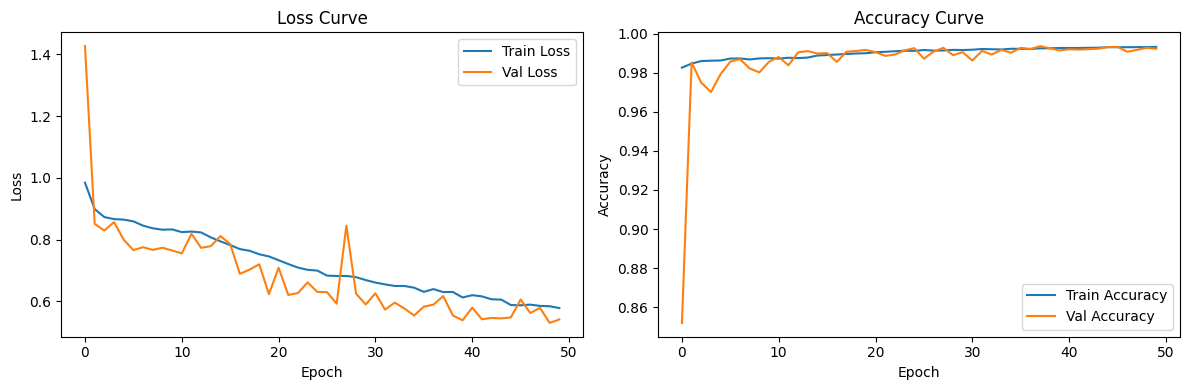

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'],label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'],label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve')

plt.tight_layout()
plt.show()

In [43]:
def load_images_coco(json_path, img_dir):
    coco = COCO(json_path)
    img_ids = coco.getImgIds()
    images = []
    for img_id in img_ids:
        img_p = coco.loadImgs(img_id)[0]
        img_path = os.path.join(img_dir, img_p["file_name"])
        img = load_img(img_path, target_size=(512,512), color_mode="grayscale")
        img = img_to_array(img)
        images.append(img)
    return np.array(images)

x_train = load_images_coco(js_train, train_img)
val_a   = load_images_coco(js_val, val_img)
x_test  = load_images_coco(js_test, test_img)

loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [44]:
model=tf.keras.models.load_model("heart.keras", compile=False)

x_test=x_test/255.0
pred_test = model.predict(x_test)

y_test=y_test.astype("float32")
pred_test=pred_test.astype("float32")

for t in [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]:
    iou=IOUScore(threshold=t)
    dice=FScore(beta=1, threshold=t)
    print(t,iou(y_test, pred_test).numpy(),dice(y_test,pred_test).numpy())

10/10 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step
0.05 0.32305273 0.48834443
0.1 0.31989408 0.48472688
0.2 0.3164264 0.48073542
0.3 0.31411362 0.4780616
0.4 0.31211495 0.47574332
0.5 0.31013942 0.4734449


In [ ]:
for t in [0.05,0.1,0.2,0.3,0.4,0.5]:

    iou=IOUScore(threshold=t)
    dice=FScore(beta=1,threshold=t)

    print(t,
          iou(y_test,pred_test).numpy(),
          dice(y_test,pred_test).numpy())

In [ ]:
best_dice=0
best_t=0

for t in np.arange(0.01,0.5,0.01):

    dice=FScore(beta=1,threshold=t)

    d=dice(y_test,pred_test).numpy()

    if d>best_dice:
        best_dice=d
        best_t=t

print("best threshold:",best_t)
print("best dice:",best_dice)

In [ ]:
pred_mask=model.predict(x_test[0:1])

mask=(pred_mask[0]>0.06).astype("uint8")

plt.figure(figsize=(8,8))
plt.imshow(x_test[0].squeeze(),cmap="gray")
plt.imshow(mask.squeeze(),alpha=0.5)

plt.show()

In [ ]:
os.system("shutdown /s /t 60")

In [ ]:
print(js_tra.keys())

print(js_tra["annotations"][0])

In [ ]:
print(y_train[0].max())
print(np.sum(y_train[0]))

In [ ]:
print(tf.config.list_physical_devices("GPU"))

In [ ]:
import tensorflow as tf
print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())